In [226]:
import pandas as pd
import numpy as np
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor  
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import time 

In [227]:
#reading the  data
clean_df = pd.read_csv('./processed-data/clean-data-with-sentiment.csv')


In [228]:
# some feature engeneering 
#nDf['neighbourhood_cleansed'].unique()
from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# nDf['neighbourhood_cleansed_encoded'] = le.fit_transform(nDf['neighbourhood_cleansed'])  # IMPORTANT CHATGPT SAYS THIS MAY BE PROBLEMATIC FOR LINEAR REG !!!
# nDf['neighbourhood_cleansed_encoded'].dtype
#clean_df = pd.get_dummies(clean_df, columns=['neighbourhood_cleansed'], prefix='neigh')
#clean_df = clean_df.astype({col: 'Int64' for col in clean_df.columns if clean_df[col].dtype == 'bool'})


In [229]:
clean_df.dtypes

listing_id                       int64
latitude                       float64
longitude                      float64
accommodates                   float64
bathrooms                      float64
bedrooms                       float64
beds                           float64
price                          float64
minimum_nights                 float64
maximum_nights                 float64
minimum_minimum_nights         float64
maximum_minimum_nights         float64
minimum_maximum_nights         float64
maximum_maximum_nights         float64
minimum_nights_avg_ntm         float64
maximum_nights_avg_ntm         float64
availability_30                float64
availability_60                float64
availability_90                float64
availability_365               float64
number_of_reviews              float64
number_of_reviews_ltm          float64
number_of_reviews_l30d         float64
number_of_reviews_ly           float64
estimated_occupancy_l365d      float64
estimated_revenue_l365d  

In [230]:
#nDf[["comments","listing_id","price","description"]].head(25)

In [231]:
#dropping all id coloumns (just for testing)
clean_df = clean_df.loc[:, ~clean_df.columns.str.contains('id', case=False)]
clean_df = clean_df.select_dtypes(include=['int', 'float64'])

In [232]:

columns_to_drop = ["minimum_minimum_nights" , "maximum_minimum_nights" , "minimum_maximum_nights" , "maximum_maximum_nights"] #, "estimated_revenue_l365d" ]
clean_df = clean_df.drop(columns=columns_to_drop)
clean_df = clean_df.drop_duplicates()
clean_df.dtypes


latitude                       float64
longitude                      float64
accommodates                   float64
bathrooms                      float64
bedrooms                       float64
beds                           float64
price                          float64
minimum_nights                 float64
maximum_nights                 float64
minimum_nights_avg_ntm         float64
maximum_nights_avg_ntm         float64
availability_30                float64
availability_60                float64
availability_90                float64
availability_365               float64
number_of_reviews              float64
number_of_reviews_ltm          float64
number_of_reviews_l30d         float64
number_of_reviews_ly           float64
estimated_occupancy_l365d      float64
estimated_revenue_l365d        float64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communicati

In [233]:
correlations = clean_df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(correlations)

price                          1.000000
accommodates                   0.519946
bathrooms                      0.483732
beds                           0.480714
bedrooms                       0.398584
estimated_revenue_l365d        0.348026
latitude                       0.152106
review_scores_location         0.111490
longitude                      0.106249
review_scores_cleanliness      0.091751
availability_30                0.083563
availability_365               0.083264
review_scores_rating           0.074673
availability_60                0.062525
maximum_nights                 0.058760
review_scores_accuracy         0.050262
availability_90                0.047465
maximum_nights_avg_ntm         0.043593
review_scores_value            0.021195
review_scores_communication    0.014490
review_scores_checkin          0.004653
number_of_reviews_l30d         0.000140
reviews_per_month             -0.004379
comment_score                 -0.017162
number_of_reviews_ltm         -0.021888


In [234]:
features = clean_df.drop(columns=['price'])  
targets = clean_df['price']


In [235]:

# features = features.drop(columns=[
#     'estimated_occupancy_l365d',
#     'reviews_per_month',
#     'number_of_reviews',
#     'number_of_reviews_ltm',
#     'number_of_reviews_l30d',
#     'number_of_reviews_ly',
#     'availability_eoy',
#     'availability_365'
# ])



In [236]:
features.dtypes

latitude                       float64
longitude                      float64
accommodates                   float64
bathrooms                      float64
bedrooms                       float64
beds                           float64
minimum_nights                 float64
maximum_nights                 float64
minimum_nights_avg_ntm         float64
maximum_nights_avg_ntm         float64
availability_30                float64
availability_60                float64
availability_90                float64
availability_365               float64
number_of_reviews              float64
number_of_reviews_ltm          float64
number_of_reviews_l30d         float64
number_of_reviews_ly           float64
estimated_occupancy_l365d      float64
estimated_revenue_l365d        float64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communication    float64
review_scores_location   

In [237]:
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=1)               

In [ ]:
# random forest model
print("Training RF model...")

estimators_list = [200] ## no big diffrence
mse_scores = []

for n in estimators_list:
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    print(f"n_estimators = {n} --> MSE: {mse:.2f}")

Training model...
n_estimators = 200 --> MSE: 5910.27


In [239]:
features = features.reset_index(drop=True)
features.loc[50]
# what ? why are they normalized ? 

latitude                       0.350712
longitude                     -1.831826
accommodates                   0.261062
bathrooms                     -0.424489
bedrooms                       0.453092
beds                          -0.578410
minimum_nights                -0.606687
maximum_nights                 1.499776
minimum_nights_avg_ntm        -0.647340
maximum_nights_avg_ntm        -0.048069
availability_30                0.100281
availability_60                0.132636
availability_90                0.200204
availability_365              -1.443677
number_of_reviews              2.560213
number_of_reviews_ltm         -0.509254
number_of_reviews_l30d         0.969671
number_of_reviews_ly          -0.592123
estimated_occupancy_l365d     -0.772537
estimated_revenue_l365d       -0.581701
review_scores_rating          -0.103609
review_scores_accuracy         0.195153
review_scores_cleanliness      0.059134
review_scores_checkin          0.004856
review_scores_communication    0.079327


In [240]:
features = features.drop_duplicates()

In [241]:
features

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,...,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,comment_score
0,0.997671,1.630331,-0.557323,-0.424489,-0.417334,-0.578410,0.250495,1.499776,0.208794,-0.048069,...,-0.302706,6.764686e-01,0.746515,6.271915e-01,0.499287,4.050737e-01,0.314223,0.729704,-9.355214e-01,0.393680
1,-0.275907,-0.444005,-0.557323,-0.424489,-0.417334,-0.578410,-0.640975,-1.109800,-0.681586,-0.048069,...,-0.407732,2.084219e-01,0.332993,4.693977e-01,0.334476,1.517150e-01,-0.685425,0.404026,-6.752172e-01,0.390922
2,-0.290895,-0.382939,0.261062,-0.424489,-1.287761,0.061387,-0.640975,0.503851,-0.681586,-0.048074,...,-0.281977,2.084219e-01,0.160693,3.116039e-01,0.202628,3.688796e-01,-0.788837,0.295467,-6.582409e-01,0.379142
3,0.555184,-0.161970,-0.148131,-0.424489,-1.287761,-0.578410,2.376306,1.499776,2.332007,-0.048069,...,-0.663388,-1.289328e+00,-1.183252,-2.880124e-01,-0.951043,-3.069559e+00,0.831282,0.159768,-1.014744e+00,0.385997
4,0.515217,-0.194077,-0.557323,-0.424489,-1.287761,-0.578410,0.353357,1.499776,0.304681,-0.048069,...,-0.663388,8.012811e-01,0.746515,1.222514e-01,0.499287,5.498500e-01,0.831282,0.512585,-1.020403e+00,0.472414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3616,1.118745,0.913361,1.079447,0.426131,1.323519,0.701183,-0.572400,-0.416434,-0.616520,-0.048078,...,-0.663388,2.771394e-15,0.000000,5.605961e-15,0.000000,3.214681e-15,0.000000,0.000000,-1.256503e-16,0.000000
3617,0.768934,0.334107,1.079447,1.276752,0.453092,0.701183,-0.709549,-0.416434,-0.750076,-0.048078,...,-0.663388,2.771394e-15,0.000000,5.605961e-15,0.000000,3.214681e-15,0.000000,0.000000,-1.256503e-16,0.000000
3618,-0.627883,-0.785576,1.897832,-0.424489,1.323519,0.701183,-0.709549,-0.416434,-0.667888,-0.048078,...,-0.663388,2.771394e-15,0.000000,5.605961e-15,0.000000,3.214681e-15,0.000000,0.000000,-1.256503e-16,0.000000
3619,0.859872,0.369572,1.488639,1.276752,2.193945,1.980777,-0.572400,-0.416434,-0.616520,-0.048078,...,-0.663388,2.771394e-15,0.000000,5.605961e-15,0.000000,3.214681e-15,0.000000,0.000000,-1.256503e-16,0.000000


In [258]:
# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Show a few rows
print(comparison_df.tail(20))

     Actual   Predicted
705   122.0  218.828796
706    60.0   53.083519
707   169.0  230.349854
708   299.0  243.581406
709   135.0  148.955170
710   225.0  214.233978
711   373.0  446.856445
712    59.0  122.685127
713   205.0  175.016525
714   291.0  297.136627
715    78.0   21.978041
716   395.0  273.641113
717   116.0  113.643700
718   254.0  305.379242
719    60.0  107.128738
720   215.0  211.114655
721   129.0  186.467667
722    45.0   75.874115
723    58.0   57.085899
724   182.0  258.127045


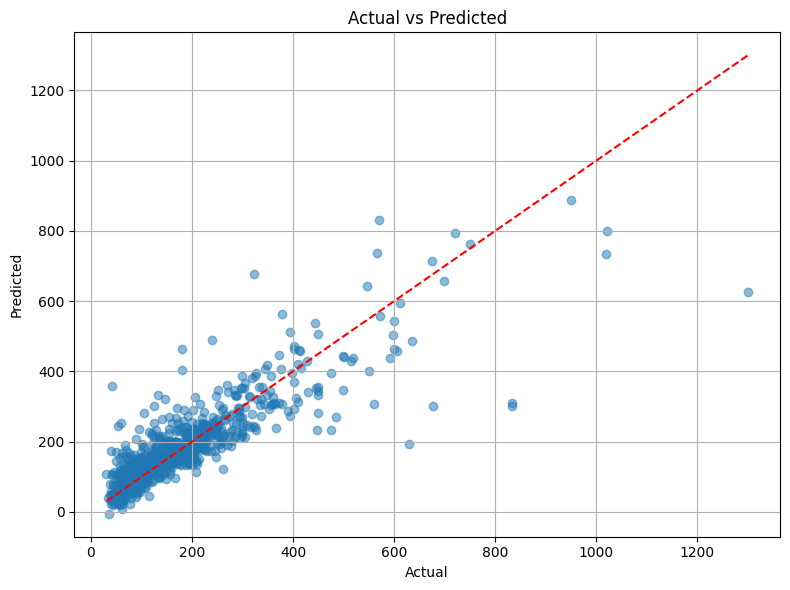

In [259]:
# Angenommen, dein DataFrame heißt comparison_df
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(comparison_df['Actual'], comparison_df['Predicted'], alpha=0.5)
plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         color='red', linestyle='--')  # Diagonale Linie (Ideal-Fall)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

In [244]:
import shap

# Create a SHAP explainer for tree-based models
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer(X_train.sample(100))

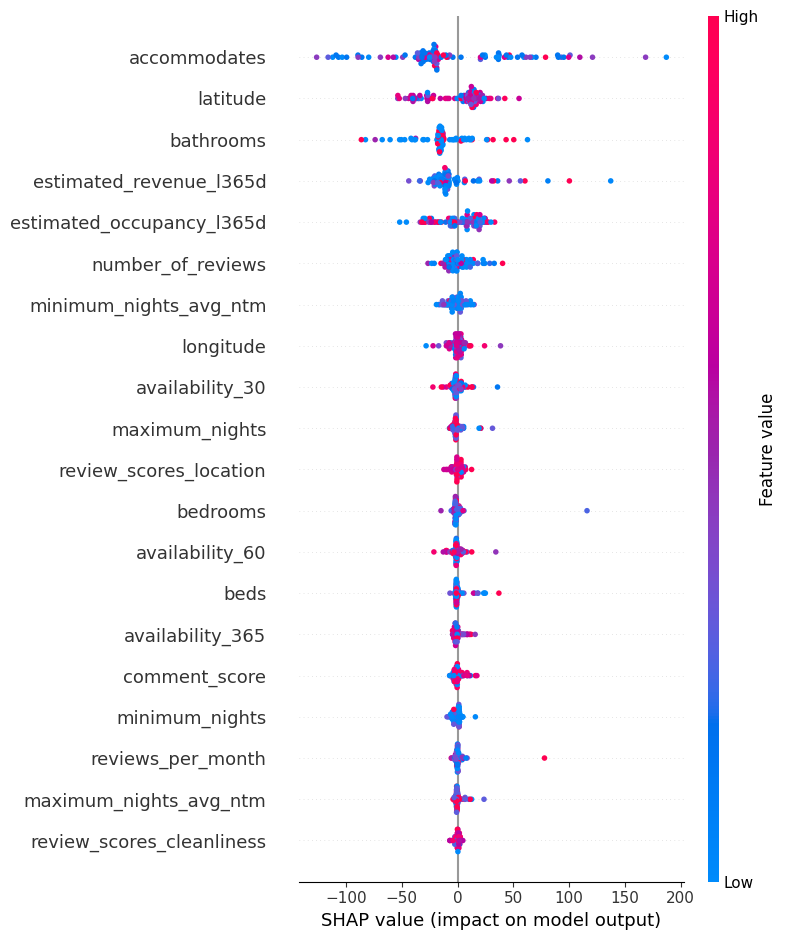

In [245]:
shap.summary_plot(shap_values, X_test.sample(100))

## XGBoost Try

In [268]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

print("Training XGBoost model...")

estimators_list = [500]  # Anzahl Trees
mse_scores = []

for n in estimators_list:
    model = XGBRegressor(n_estimators=n, random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    print(f"n_estimators = {n} --> MSE: {mse:.2f}")

Training XGBoost model...
n_estimators = 500 --> MSE: 5002.15


In [ ]:
xgb = XGBRegressor(random_state=42, verbosity=0)

# Grid mit Parametern
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.05, 0.1, 0.01],
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1  # parallele Threads
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"\nTest MSE of best model: {mse:.2f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters:
{'learning_rate': 0.05, 'n_estimators': 1000}

Test MSE of best model: 4348.37


In [270]:
import pandas as pd

# assume you already have y_test and y_pred
df_compare = pd.DataFrame({
    'Actual':    y_test,
    'Predicted': y_pred
})

# show a small sample (first 20 rows)
print(df_compare.head(20))

      Actual   Predicted
268    179.0  156.332214
1605   165.0  157.488663
368    110.0  139.151688
1388   239.0  231.913818
1634   205.0  207.267624
2287    56.0   67.663315
1139   251.0  227.604858
1949   188.0  183.354218
1374   288.0  265.844971
1476   248.0  238.798553
3522    58.0   40.117420
2738   134.0  211.072662
79     270.0  289.988953
855    227.0  233.847549
2583   155.0  169.911072
1700   144.0  135.690903
2076   124.0  141.408051
3373   183.0  169.996811
1413   299.0  238.744461
2172   115.0  129.414291


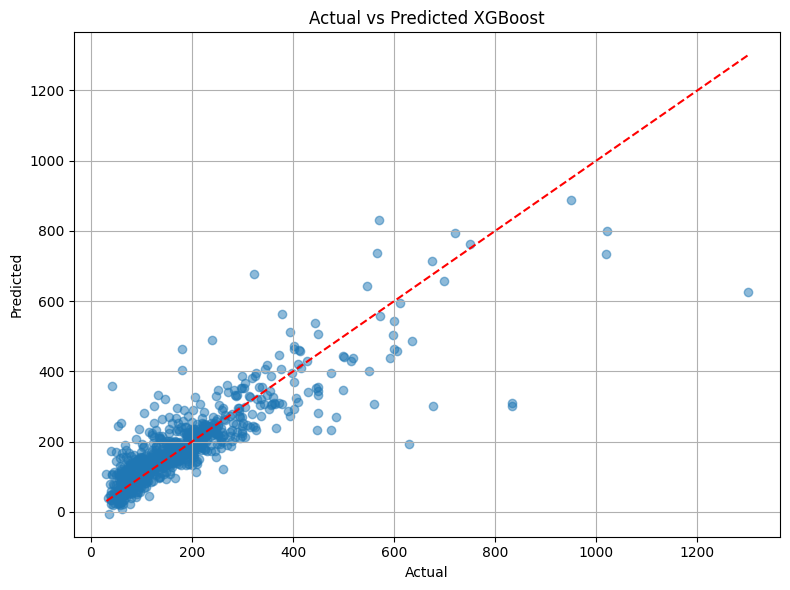

In [271]:
plt.figure(figsize=(8, 6))
plt.scatter(comparison_df['Actual'], comparison_df['Predicted'], alpha=0.5)
plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         color='red', linestyle='--')  # Diagonale Linie (Ideal-Fall)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted XGBoost')
plt.grid(True)
plt.tight_layout()
plt.show()